# Smeaheia Workbook to Leakage Tool Prototype

This notebook reads the Smeaheia benchmark workbook, builds `WellProcessed` and `Pressure` from the well and scenario sheets, extracts the geometry and barrier values needed by `leakage_tool_prototype`, generates its three CSV inputs, and runs the prototype case.

## Prerequisites

Running this notebook requires a local clone of the leakage tool prototype (`leakage_model` package) under `work/benchmark/repos/leakage_tool_prototype`:

```bash
mkdir -p work/benchmark/repos
git clone git@gitlab.sintef.no:1630/research-projects/legacy/leakage_tool_prototype.git work/benchmark/repos/leakage_tool_prototype
```

See [docs/openiam_benchmarking.md](../docs/openiam_benchmarking.md) for details. This checkout lives under the SCREEN-ignored `work/` folder and is not part of this repository.

## Translation Assumptions

- The Smeaheia workbook (Header, HoleCasings, Plugs, Stratigraphy sheets) is the source of truth for well geometry.
- The SubsurfaceAssumptions sheet provides pressure datum and fluid contact depths for scenario configuration.
- `WellProcessed` TVDMSL values are computed from workbook geometry and remain the source of truth for depth consistency.
- Prototype CSV tables are generated from `WellProcessed` geometry values.
- The prototype normalizes geometry internally after reading the CSVs; the adapter does not shift the input values.
- The default prototype geometry is determined by populated casing-table geometry and hole-depth slots, not by `sc_total_depth` alone.
- Open-hole continuation below the deepest casing must be explicitly added to a hole-depth slot. This notebook sets the evaluation bottom to the base of the first reservoir/flow unit and adds an open-hole slot to that depth.
- Cement and mechanical plugs are both passed as prototype plug intervals.
- The mechanical plug uses its SCREEN `cement_perm` as an effective prototype permeability.
- The full prototype depth profile uses the WellClass hydrostatic pressure curve. The WellClass brine and fluid-pressure curves are not passed through the well; they are sampled only once to set the corresponding bottom boundary pressure.
- The top boundary remains the hydrostatic pressure at the top prototype node; the prototype solves the internal well pressure between the hydrostatic top and selected bottom boundary.
- Formation interval permeability and source-face permeability are separate assumptions. The former controls radial exchange between the wellbore and surrounding intervals; the latter controls axial entry from the pressurized reservoir through the bottom circular well face.
- The bottom ghost/source face lies 1 m below the modeled reservoir interval, so it is explicitly assigned the reservoir permeability rather than the overburden value. Its circular or annular area is determined by the terminal well path geometry.

In [37]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd

repo_root = Path.cwd()
if not (repo_root / "pyproject.toml").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "pyproject.toml").exists())

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
prototype_root = repo_root / "work" / "benchmark" / "repos" / "leakage_tool_prototype"
if not prototype_root.exists():
    raise FileNotFoundError(
        f"Expected leakage_tool_prototype checkout at {prototype_root}\n"
        "Clone it under work/benchmark/repos/leakage_tool_prototype; see docs/openiam_benchmarking.md."
    )
if str(prototype_root) not in sys.path:
    sys.path.insert(0, str(prototype_root))

case_root = repo_root / "notebooks" / "results" / "08B_smeaheia_leakage_tool"
csv_root = case_root / "prototype_csv"
visual_root = case_root / "prototype_visualizations"
csv_root.mkdir(parents=True, exist_ok=True)
visual_root.mkdir(parents=True, exist_ok=True)

# Load well and scenario data from the Smeaheia benchmark workbook
smeaheia_workbook = repo_root / "test_data" / "examples" / "smeaheia" / "smeaheia_bm_case.xlsx"
if not smeaheia_workbook.exists():
    raise FileNotFoundError(smeaheia_workbook)

print(f"Workbook source: {smeaheia_workbook.relative_to(repo_root)}")


Workbook source: test_data/examples/smeaheia/smeaheia_bm_case.xlsx


In [38]:
from leakage_model.automated_well_construction import automated_well_construction
from leakage_model.plotting import visualizeAll
from leakage_model.reservoir_permeabilities import MILLIDARCY
from leakage_model.state import FormationBC, TopBC
from src.WellClass.libs.well_class.well_processed import WellProcessed
from src.WellClass.libs.well_pressure import Pressure
from src.WellClass.libs.utils import xlsx_to_well_model, xlsx_to_simulation_design


## SCREEN Processing: Load Well, Scenarios, and Generate Geometry Tables

This section consolidates all SCREEN workbook processing:
1. Load well geometry (Header, HoleCasings, Plugs, Stratigraphy)
2. Load scenario assumptions (baseline case from SubsurfaceAssumptions)
3. Build WellProcessed and Pressure objects
4. Generate prototype CSV tables (reference, casing, plugs)
5. Display summary and QC visualizations

By the end of this section, all SCREEN-related work is complete and ready for prototype execution.


In [39]:
# ============================================================================
# STEP 1: Parse well geometry from workbook
# ============================================================================
well_model = xlsx_to_well_model(smeaheia_workbook)
processed_well = WellProcessed.from_pydantic(well_model)
spec = well_model.spec
header = spec.well_header.model_dump()

# ============================================================================
# STEP 2: Parse scenario assumptions - use baseline case ONLY
# ============================================================================
simulation_design = xlsx_to_simulation_design(smeaheia_workbook)
if not simulation_design.scenarios:
    raise ValueError("No scenarios found in SubsurfaceAssumptions sheet")

scenario = simulation_design.scenarios[0]
scenario_dict = scenario.model_dump()
print(f"Loaded scenario: {scenario_dict.get('case_name', 'baseline')}")

# ============================================================================
# STEP 3: Extract geometry records
# ============================================================================
hole_records = [record for record in processed_well.hole_casings if record["type"] == "hole"]
casing_records = [record for record in processed_well.hole_casings if record["type"] == "casing"]
cement_records = [record for record in processed_well.hole_casings if record["type"] == "casing cement"]
plug_records = [record for record in processed_well.plugs]

reservoir_tops = [
    float(record["tvd_msl_top"])
    for record in processed_well.stratigraphy
    if record["unit_type"] == "reservoir"
]
well_bottom_msl = float(header["total_depth_rkb"]) - float(header["depth_reference_rkb"])

# Display well summary
summary_data = [
    ["well_id", header["unique_wellbore_identifier"]],
    ["well_bottom_msl", well_bottom_msl],
    ["hole_count", len(hole_records)],
    ["casing_count", len(casing_records)],
    ["cement_interval_count", len(cement_records)],
    ["plug_count", len(plug_records)],
    ["scenario_case_name", scenario_dict.get("case_name", "N/A")],
    ["z_fluid_contact_msl", scenario_dict.get("z_fluid_contact", "N/A")],
    ["p_fluid_contact_bar", scenario_dict.get("p_fluid_contact", "N/A")],
]
print("\nWell and Scenario Summary:")
pd.DataFrame(summary_data, columns=["quantity", "value"])


Loaded scenario: base_case

Well and Scenario Summary:


,quantity,value
0,well_id,NO 32/4-1
1,well_bottom_msl,3162.5
2,hole_count,4
3,casing_count,3
4,cement_interval_count,3
5,plug_count,1
6,scenario_case_name,base_case
7,z_fluid_contact_msl,1282.5
8,p_fluid_contact_bar,154.99


### Subsection: Generate Prototype CSV Tables from WellProcessed

The prototype reader uses one row per well in each table and supports six casing slots and five plug slots. Empty slots are left blank. The casing table uses the casing strings, while each casing's hole section is selected by the casing bottom depth.

The prototype does not infer an open-hole continuation from `sc_total_depth`. The adapter explicitly adds the final open-hole slot through `evaluation_bottom_msl`, currently the base of the first reservoir or flow unit.


In [40]:
well_id = str(header["unique_wellbore_identifier"])


def diameter_to_inches(value: object) -> float:
    if isinstance(value, (int, float)):
        return float(value)
    text = str(value).strip()
    if " " in text:
        whole, fraction = text.split(maxsplit=1)
        numerator, denominator = fraction.split("/")
        return float(whole) + float(numerator) / float(denominator)
    if "/" in text:
        numerator, denominator = text.split("/")
        return float(numerator) / float(denominator)
    return float(text)


def hole_for_bottom(bottom_msl: float) -> dict:
    candidates = [
        record for record in hole_records
        if float(record["tvd_msl_top"]) <= bottom_msl <= float(record["tvd_msl_bottom"]) + 1e-9
    ]
    if not candidates:
        candidates = sorted(
            hole_records,
            key=lambda record: abs(float(record["tvd_msl_bottom"]) - bottom_msl),
        )[:1]
    return candidates[0]


first_reservoir = min(
    (
        item for item in processed_well.stratigraphy
        if item["unit_type"] in {"reservoir", "flow_unit"}
    ),
    key=lambda item: float(item["tvd_msl_top"]),
)
evaluation_bottom_msl = float(first_reservoir["tvd_msl_bottom"])
last_hole = hole_for_bottom(evaluation_bottom_msl)

reference_row = {
    "wellname": well_id,
    "sc_ref_elev_depth": 0.0,
    "sc_seabed_depth": float(header["ground_elevation"]),
    "sc_top_res_depth": min(reservoir_tops),
    "sc_total_depth": evaluation_bottom_msl,
}
reference_csv = csv_root / "smeaheia_reference.csv"
pd.DataFrame([reference_row]).to_csv(reference_csv, index=False)

casing_row = {"wellname": well_id}
for index in range(1, 7):
    casing = casing_records[index - 1] if index <= len(casing_records) else None
    if casing is None:
        for suffix in (
            "name", "wlbCasingTop", "wlbCasingDiameter", "wlbCasingDepth",
            "wlbHoleDiameter", "wlbHoleDepth", "shoeDepth", "cement_top",
            "cement_bottom",
        ):
            casing_row[f"cs_{index}_{suffix}"] = np.nan
        continue

    hole = hole_for_bottom(float(casing["tvd_msl_bottom"]))
    casing_diameter_in = diameter_to_inches(casing["diameter_in"])
    matching_cement = next(
        (
            item for item in cement_records
            if abs(diameter_to_inches(item["diameter_in"]) - casing_diameter_in) < 1e-6
        ),
        None,
    )
    casing_row.update({
        f"cs_{index}_name": casing["name"],
        f"cs_{index}_wlbCasingTop": float(casing["tvd_msl_top"]),
        f"cs_{index}_wlbCasingDiameter": casing_diameter_in,
        f"cs_{index}_wlbCasingDepth": float(casing["tvd_msl_bottom"]),
        f"cs_{index}_wlbHoleDiameter": diameter_to_inches(hole["diameter_in"]),
        f"cs_{index}_wlbHoleDepth": float(hole["tvd_msl_bottom"]),
        f"cs_{index}_shoeDepth": float(casing["tvd_msl_bottom"]),
        f"cs_{index}_cement_top": float(matching_cement["tvd_msl_top"]) if matching_cement else float(casing["tvd_msl_top"]),
        f"cs_{index}_cement_bottom": float(matching_cement["tvd_msl_bottom"]) if matching_cement else float(casing["tvd_msl_bottom"]),
    })

casing_row.update({
    "cs_4_name": "Open hole to first reservoir base",
    "cs_4_wlbCasingTop": np.nan,
    "cs_4_wlbCasingDiameter": np.nan,
    "cs_4_wlbCasingDepth": np.nan,
    "cs_4_wlbHoleDiameter": diameter_to_inches(last_hole["diameter_in"]),
    "cs_4_wlbHoleDepth": evaluation_bottom_msl,
    "cs_4_shoeDepth": np.nan,
    "cs_4_cement_top": np.nan,
    "cs_4_cement_bottom": np.nan,
})

casing_csv = csv_root / "smeaheia_casing.csv"
pd.DataFrame([casing_row]).to_csv(casing_csv, index=False)

plug_row = {"well ID": well_id}
for index in range(1, 6):
    plug = plug_records[index - 1] if index <= len(plug_records) else None
    plug_row.update({
        f"pl{index}_name": plug["name"] if plug else np.nan,
        f"pl{index}_top": float(plug["tvd_msl_top"]) if plug else np.nan,
        f"pl{index}_bottom": float(plug["tvd_msl_bottom"]) if plug else np.nan,
        f"pl{index}_basetype": plug["type"] if plug else np.nan,
        f"pl{index}_typelocation": "casing" if plug else np.nan,
    })

plug_csv = csv_root / "smeaheia_plugs.csv"
pd.DataFrame([plug_row]).to_csv(plug_csv, index=False)

pd.DataFrame(
    [
        [str(reference_csv.relative_to(repo_root)), evaluation_bottom_msl],
        [str(casing_csv.relative_to(repo_root)), evaluation_bottom_msl],
        [str(plug_csv.relative_to(repo_root)), evaluation_bottom_msl],
    ],
    columns=["generated_table", "evaluation_bottom_msl"],
)

,generated_table,evaluation_bottom_msl
0,notebooks/results/08B_smeaheia_leakage_tool/pr...,1282.5
1,notebooks/results/08B_smeaheia_leakage_tool/pr...,1282.5
2,notebooks/results/08B_smeaheia_leakage_tool/pr...,1282.5


### Subsection: Generate Pressure Profile from WellClass

`Pressure` is calculated from the processed Smeaheia header and reservoir depth using the baseline scenario assumptions from the workbook. The pressure profile is exported and retained as the WellClass reference for boundary-condition coupling in prototype cases.


In [41]:
# ============================================================================
# STEP 4: Build Pressure object from baseline scenario
# ============================================================================
reservoir_intervals = [item for item in processed_well.stratigraphy if item.get("unit_type") == "reservoir"]
reservoir_top_msl = min(float(item["tvd_msl_top"]) for item in reservoir_intervals)

# Extract scenario parameters
ground_temp = float(scenario_dict.get("ground_temperature", 4.0))
geothermal_grad = float(scenario_dict.get("temperature_gradient", 31.0))
fluid_type = scenario_dict.get("fluid_type", "co2")

pressure = Pressure(
    header=processed_well.header,
    co2_datum=reservoir_top_msl,
    ground_temperature=ground_temp,
    geothermal_gradient=geothermal_grad,
    fluid_type=fluid_type,
)

# Add the baseline scenario from workbook - this is the only scenario we use
if "p_fluid_contact" not in scenario_dict:
    raise ValueError("Baseline scenario must have p_fluid_contact defined")

case_name = scenario_dict.get("case_name", "baseline")
z_contact = float(scenario_dict.get("z_fluid_contact", reservoir_top_msl))
p_contact = float(scenario_dict["p_fluid_contact"])

pressure_scenario = pressure.add_scenario(
    case_name,
    z_fluid_datum=z_contact,
    p_fluid_datum=p_contact,
)
print(f"\nPressure scenario '{case_name}': z_fluid_datum={z_contact:.1f} mMSL, p_fluid_datum={p_contact:.1f} bar")

# Export pressure table
pressure_table = pd.DataFrame({
    "depth_msl_m": pressure.table.depth,
    "hydrostatic_pressure_bar": pressure.table.hydrostatic_pressure,
    "brine_pressure_bar": pressure_scenario.brine_pressure,
    "fluid_pressure_bar": pressure_scenario.fluid_pressure,
    "min_horizontal_stress_bar": pressure.table.min_horizontal_stress,
})
pressure_csv = case_root / "smeaheia_pressure_profile.csv"
pressure_table.to_csv(pressure_csv, index=False)
print(f"Pressure table saved to {pressure_csv.relative_to(repo_root)}")
pressure_table.head()



Pressure scenario 'base_case': z_fluid_datum=1282.5 mMSL, p_fluid_datum=155.0 bar
Pressure table saved to notebooks/results/08B_smeaheia_leakage_tool/smeaheia_pressure_profile.csv


,depth_msl_m,hydrostatic_pressure_bar,brine_pressure_bar,fluid_pressure_bar,min_horizontal_stress_bar
0,0.0,1.013250,25.446605,43.147451,1.013250
1,10.0,2.023335,26.456690,44.037941,2.023335
2,20.0,3.033420,27.466775,44.929309,3.033420
3,30.0,4.043505,28.476860,45.821553,4.043505
4,40.0,5.053590,29.486945,46.714667,5.053590



Baseline scenario: p_datum=155.0 bar @ z_datum=1282.5 mMSL; p_delta=+24.4 bar; p_MSAD=114.1 bar @ z_MSAD=793.0 mMSL


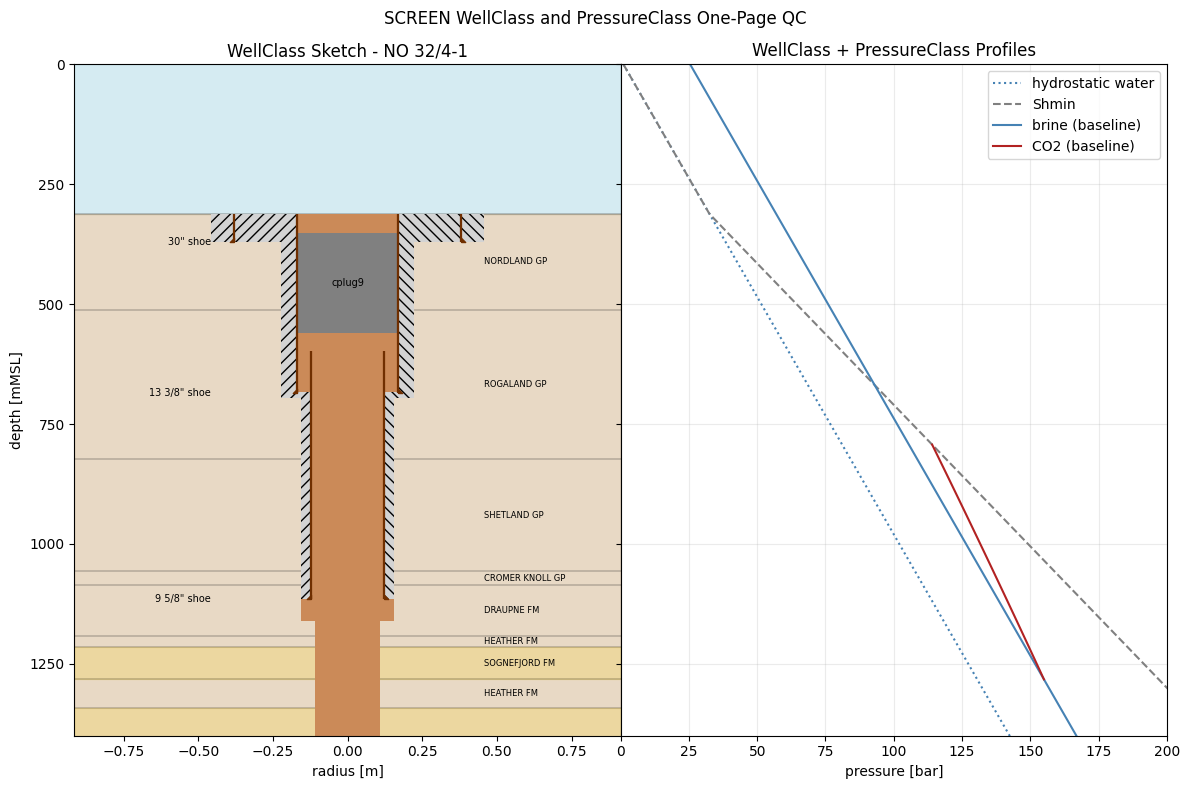


SCREEN WELLCLASS/PRESSURECLASS PRE-PROTOTYPE QC COMPLETE


In [42]:
# ============================================================================
# STEP 5: WellClass + PressureClass one-page QC
# ============================================================================
import matplotlib.pyplot as plt
from src.WellClass.libs.plotting.plot_sketch import plot_sketch

pr_table = pressure.table
display = pressure_scenario.display_curves()

fig, (ax_well, ax_pressure) = plt.subplots(1, 2, figsize=(12, 8), sharey=True)
plot_sketch(processed_well, ax=ax_well)
ax_well.set_title('WellClass Sketch - NO 32/4-1')

ax_pressure.plot(pr_table.hydrostatic_pressure, pr_table.depth, color='steelblue', linestyle=':', label='hydrostatic water')
ax_pressure.plot(pr_table.min_horizontal_stress, pr_table.depth, color='gray', linestyle='--', label='Shmin')
ax_pressure.plot(display['brine_pressure'], display['brine_depth'], color='steelblue', label='brine (baseline)')
ax_pressure.plot(display['fluid_pressure'], display['fluid_depth'], color='firebrick', label='CO2 (baseline)')

print(
    f"\nBaseline scenario: p_datum={pressure_scenario.p_fluid_datum:.1f} bar @ z_datum={pressure_scenario.z_fluid_datum:.1f} mMSL; "
    f"p_delta={pressure_scenario.p_delta:+.1f} bar; p_MSAD={pressure_scenario.p_MSAD:.1f} bar @ z_MSAD={pressure_scenario.z_MSAD:.1f} mMSL"
)

ax_pressure.set_title('WellClass + PressureClass Profiles')
ax_pressure.set_xlabel('pressure [bar]')
ax_pressure.set_ylim(0, 1400)
ax_pressure.set_xlim(0, 200)
ax_pressure.invert_yaxis()
ax_pressure.grid(alpha=0.25)
ax_pressure.legend()

ax_pressure.set_ylabel('')
ax_pressure.tick_params(labelleft=False)

fig.suptitle('SCREEN WellClass and PressureClass One-Page QC')
fig.tight_layout()
fig.subplots_adjust(wspace=0)
plt.show()

print("\n" + "="*70)
print("SCREEN WELLCLASS/PRESSURECLASS PRE-PROTOTYPE QC COMPLETE")
print("="*70)


## Pre-prototype checkpoint

Run and inspect the preceding WellClass + PressureClass one-page QC before running any prototype cell. This establishes the well geometry, hydrostatic profile, fluid-pressure profile, datum, and reservoir contact. Prototype execution and all prototype-specific post-processing begin only after this checkpoint.

## Prototype Execution

All SCREEN processing is now complete. The following sections build and run three independent prototype cases using the generated CSV tables and WellClass pressure profile. Each fluid case (water, dummy CO2, and real thermopack CO2) uses a fresh prototype solver initialized from the same geometry, with boundary conditions coupled to the baseline pressure scenario.


### Interpreting the pressure profile

This prototype solves a steady-state flow problem. It does not simulate the time required for the well to equilibrate. The WellClass hydrostatic profile is imposed on the formation at all nodes, while the selected brine or fluid pressure is imposed at the axial bottom boundary only. The resulting pressure difference drives a steady leakage rate through the well's hydraulic conductance.

The bottom source enters through the axial bottom boundary and then flows upward through the well. The bottom boundary face is 1 m below the modeled well interval, so it inherits the permeability of the last well node; otherwise the depth-based formation classification would incorrectly assign zero permeability and seal the source. `bottom_flow_kg_s` is the inflow through this axial bottom link, while `formation_exchange_kg_s_positive_outward` also includes radial formation exchange along the well.

The prototype top boundary is at the top of the translated well geometry (`prototype_origin_msl`), not necessarily at surface elevation. The displayed top pressure is therefore the hydrostatic pressure at that well-top depth.

In [ ]:
# Unit conversion and prototype discretization settings.
MILLIDARCY = 9.869233e-16  # m² per mD

def md_to_m2(permeability_md):
    return permeability_md * MILLIDARCY

def m2_to_md(permeability_m2):
    return permeability_m2 / MILLIDARCY


n_cells = 120
filenames = [str(reference_csv), str(casing_csv), str(plug_csv)]
material_props = {
    "drMA": 0.0e-2,  # Microannulus aperture/thickness used to create the leakage path around plugs and casing [m]
    "k_cement": md_to_m2(10), # Effective permeability assigned to cement plugs and cement sheath [m^2]
    "phi_cement": 0.01,  # Porosity assigned to cement plugs and cement sheath [fraction]
    "k_casing": 5.0e-19,  # Effective permeability assigned to the casing [m^2]
    "phi_casing": 0.01,  # Porosity assigned to the casing [fraction]
}

reservoir_k_md = 500
prototype_origin_msl = min(float(record["tvd_msl_top"]) for record in hole_records)

# Assign formation permeability from the translated stratigraphy.
def formation_permeability_by_depth(
    physical_depth,
    processed_well,
    reservoir_k_md=0,
    overburden_k_md=0,
):
    formation_k = np.zeros(len(physical_depth))

    for index, depth in enumerate(physical_depth):
        in_reservoir = any(
            item["unit_type"] in ["reservoir", "flow_unit"]
            and item["tvd_msl_top"] <= depth <= item["tvd_msl_bottom"]
            for item in processed_well.stratigraphy
        )

        formation_k[index] = md_to_m2(
            reservoir_k_md if in_reservoir else overburden_k_md
        )

    return formation_k


# Use hydrostatic pressure at every prototype depth; sample overpressure only at the bottom face.
def apply_pressure_table_boundary(solver, bottom_pressure_column: str, gas_fraction: float):
    """Map the WellClass pressure model onto prototype boundary conditions.

    Hydrostatic pressure is used at every prototype depth. The selected
    brine/fluid pressure column contributes only the bottom source-face
    pressure; it is not passed through the well profile.
    """
    # Build the prototype node depths plus the extra bottom ghost-face depth.
    physical_depth = prototype_origin_msl + np.append(
        solver.well.xList,
        solver.well.wellLen + solver.well.bottom_BC_dist,
    )

    # Build the full hydrostatic profile and sample the bottom overpressure once.
    hydrostatic_pressure_pa = np.interp(
        physical_depth,
        pressure_table["depth_msl_m"],
        pressure_table["hydrostatic_pressure_bar"],
    ) * 1.0e5
    bottom_pressure_pa = np.interp(
        physical_depth[-1],
        pressure_table["depth_msl_m"],
        pressure_table[bottom_pressure_column],
    ) * 1.0e5

    # FormationBC follows hydrostatic pressure except at the bottom source face.
    pressure_pa = hydrostatic_pressure_pa.copy()
    pressure_pa[-1] = bottom_pressure_pa
    temperature_c = np.interp(physical_depth, pressure.table.depth, pressure.table.temperature)
    solver.T = temperature_c[:-1] + 273.15
    solver.p_top = float(hydrostatic_pressure_pa[0])
    solver.p_bottom = float(bottom_pressure_pa)

    # Preserve reservoir mobility on the bottom ghost face below the reservoir.
    formation_size = solver.well.N + 1
    formation_k = formation_permeability_by_depth(
        physical_depth,
        processed_well,
        reservoir_k_md=0,
    )
    formation_k[-1] = md_to_m2(reservoir_k_md)

    # Evaluate density, viscosity, and phase mobility at each boundary pressure.
    formation_phi = np.full(formation_size, 0.25)  # Porosity assigned to the formation [fraction]
    formation_z = np.full(formation_size, gas_fraction)
    formation_rho = np.zeros(formation_size)
    formation_mu = np.zeros(formation_size)
    formation_k_rel_gas = np.zeros(formation_size)
    formation_k_rel_water = np.zeros(formation_size)
    for index, p_value in enumerate(pressure_pa):
        state = solver.fluid.ptz_flash(p_value, temperature_c[index] + 273.15, gas_fraction)
        formation_rho[index] = state.rho
        formation_mu[index] = state.mu
        formation_k_rel_gas[index], formation_k_rel_water[index] = solver.fluid.relPerm_comp(state, True)

    # Register the radial formation boundaries and the top axial boundary.
    solver.BC_for = FormationBC(
        p=pressure_pa, z=formation_z, k=formation_k, phi=formation_phi,
        rho=formation_rho, mu=formation_mu,
        k_rel_gas=formation_k_rel_gas, k_rel_water=formation_k_rel_water,
    )
    top_state = solver.fluid.ptz_flash(solver.p_top, solver.T[0], gas_fraction)
    top_k_rel_gas, top_k_rel_water = solver.fluid.relPerm_comp(top_state, False)
    solver.BC_top = TopBC(
        p=solver.p_top, z=gas_fraction, k=np.inf, phi=1.0,
        rho=top_state.rho, mu=top_state.mu,
        k_rel_gas=top_k_rel_gas, k_rel_water=top_k_rel_water,
    )
    return solver.p_top / 1.0e5, solver.p_bottom / 1.0e5







# Run non-Thermopack cases first to isolate geometry and permeability effects.
case_definitions = [
    # TODO: replace dummy water after Thermopack PR water flash is stabilized for Smeaheia states.
    ("water", "dummy", "H2O", "brine_pressure_bar", 0.0),
    ("dummy_co2", "dummy", "CO2", "fluid_pressure_bar", 1.0),
    ("co2", "pure_fluid", "CO2", "fluid_pressure_bar", 1.0),
]
prototype_solvers = {}
prototype_results = {}
summary_rows = []
for case_name, thermo_model, components, pressure_column, gas_fraction in case_definitions:
    solver = automated_well_construction(
        n_cells, filenames, f"smeaheia_{case_name}_pressure_coupled",
        well_id, material_props, False,
        thermo_model=thermo_model, components=components,
    )
    top_pressure_bar, bottom_pressure_bar = apply_pressure_table_boundary(solver, pressure_column, gas_fraction)
    # Avoid the analytical Jacobian for the stiff low-permeability plug case.
    result = solver.solve_system(use_jacobian=False)
    prototype_solvers[case_name] = solver
    prototype_results[case_name] = result
    flows = result.flows.total()
    summary_rows.append({
        "case": case_name,
        "fluid": f"{thermo_model} {components}",
        "boundary_source": "hydrostatic profile plus one bottom pressure sample",
        "bottom_pressure_column": pressure_column,
        "convergence_status": result.convergence.status,
        "top_pressure_bar": top_pressure_bar,
        "bottom_pressure_bar": bottom_pressure_bar,
        "well_length_m": solver.well.wellLen,
        "node_count": len(solver.well.nodes),
        "path_count": len(solver.well.paths),
        "top_leak_kg_s_positive_upward": -float(np.sum(flows.top)),
        "bottom_flow_kg_s": float(np.sum(flows.bottom)),
        "formation_exchange_kg_s_positive_outward": float(np.sum(flows.formation)),
    })

# Summarize convergence and the main boundary flows.
smeaheia_summary = pd.DataFrame(summary_rows)
smeaheia_summary


Newton finished after 3129 function evaluations.
Mass-balance check:
  max |residual| = 4.276e-10 kg/s,  max |flow| = 1.939e-05 kg/s,  ratio = 2.20e-05
-> WARN (relative mass-balance residual between 1e-06 and 1e-03)
   The solution is approximate; engineering-grade results may still be useful but the iteration did not fully converge.

______________________________________________________________

H2O leakage at the top of well into the air is 1.939e-05 kg/s.
H2O leakage radially into the reservoir is 0.000e+00 kg/s.
H2O leakage into bottom of well is 1.939e-05 kg/s.

______________________________________________________________


Newton finished after 3023 function evaluations.
Mass-balance check:
  max |residual| = 5.186e-14 kg/s,  max |flow| = 8.805e-06 kg/s,  ratio = 5.89e-09
-> PASS (relative mass-balance residual < 1e-06)
   (scipy heuristic reported 'The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.', but the mass-balanc

In [ ]:
# Store all solved and prescribed pressures in one long-form table for plotting and QC.
pressure_rows = []

for case_name, solver in prototype_solvers.items():
    result = prototype_results[case_name]
    origin_msl = prototype_origin_msl

    # Solved well-node pressures, one row for each network node and path.
    for node, pressure_pa in zip(solver.well.nodes, result.p):
        path = solver.well.paths[node.inPath]
        pressure_rows.append({
            "case": case_name,
            "data_type": "well_node",
            "path_type": path.pathType,
            "depth_relative_m": node.x,
            "depth_tvdmsl_m": origin_msl + node.x,
            "pressure_bar": pressure_pa / 1.0e5,
        })

    # Prescribed formation pressures, including the overpressured bottom source face.
    formation_depths = list(solver.well.xList) + [
        solver.well.wellLen + solver.well.bottom_BC_dist
    ]
    for depth_relative_m, pressure_pa in zip(
        formation_depths,
        solver.BC_for.p,
    ):
        pressure_rows.append({
            "case": case_name,
            "data_type": "formation_boundary",
            "path_type": "formation",
            "depth_relative_m": depth_relative_m,
            "depth_tvdmsl_m": origin_msl + depth_relative_m,
            "pressure_bar": pressure_pa / 1.0e5,
        })

    # Add explicit top and bottom ghost-boundary rows for boundary comparisons.
    pressure_rows.extend([
        {
            "case": case_name,
            "data_type": "top_boundary",
            "path_type": "TopBC",
            "depth_relative_m": 0.0,
            "depth_tvdmsl_m": origin_msl,
            "pressure_bar": solver.p_top / 1.0e5,
        },
        {
            "case": case_name,
            "data_type": "bottom_boundary",
            "path_type": "BottomBC",
            "depth_relative_m": solver.well.wellLen + solver.well.bottom_BC_dist,
            "depth_tvdmsl_m": origin_msl + solver.well.wellLen + solver.well.bottom_BC_dist,
            "pressure_bar": solver.p_bottom / 1.0e5,
        },
    ])

# Keep solved nodes, formation faces, and ghost boundaries distinguishable for plots.
prototype_pressure_data = pd.DataFrame(pressure_rows)
prototype_pressure_data

,case,data_type,path_type,depth_relative_m,depth_tvdmsl_m,pressure_bar
0,water,well_node,RBP,6.583333,318.583333,33.838698
1,water,well_node,RBP,19.750000,331.750000,35.130348
2,water,well_node,RBP,32.916667,344.916667,36.421998
3,water,well_node,P,44.250000,356.250000,37.880722
4,water,well_node,P,53.750000,365.750000,39.224124
...,...,...,...,...,...,...
958,co2,formation_boundary,formation,944.571429,1256.571429,127.937639
959,co2,formation_boundary,formation,961.857143,1273.857143,129.683643
960,co2,formation_boundary,formation,971.500000,1283.500000,155.070993
961,co2,top_boundary,TopBC,0.000000,312.000000,33.192873


In [ ]:
well_pressure_profile = prototype_pressure_data.query(
    "case == 'co2' and data_type == 'well_node'"
)
well_pressure_profile.groupby("path_type").agg(
    depth_min_m=("depth_relative_m", "min"),
    depth_max_m=("depth_relative_m", "max"),
    pressure_min_bar=("pressure_bar", "min"),
    pressure_max_bar=("pressure_bar", "max"),
    node_count=("pressure_bar", "size"),
).sort_values("depth_min_m")

,depth_min_m,depth_max_m,pressure_min_bar,pressure_max_bar,node_count
path_type,,,,,
BPM,6.583333,792.923913,33.271147,140.757282,56
C,6.583333,792.923913,33.260370,140.757282,61
MA,6.583333,792.923913,33.271138,140.757282,76
RBP,6.583333,961.857143,33.249284,154.291149,46
P,44.250000,238.954545,34.574308,91.537415,14
A,294.900000,362.100000,98.870376,104.703713,5


In [ ]:
from collections import Counter

path_inventory_solver = prototype_solvers["co2"]
path_type_counts = Counter(path.pathType for path in path_inventory_solver.well.paths)
pd.DataFrame(sorted(path_type_counts.items()), columns=["path_type", "count"])

,path_type,count
0,A,1
1,BPM,12
2,C,13
3,MA,18
4,P,3
5,RBP,9


In [ ]:
path_rows = []
for path in path_inventory_solver.well.paths:
    path_rows.append({
        "name": path.name,
        "path_type": path.pathType,
        "top_m": path.x_t,
        "bottom_m": path.x_b,
        "inner_radius_m": path.r_i,
        "outer_radius_m": path.r_o,
        "kx_m2": path.kx,
        "kr_m2": path.kr,
    })

path_inventory = pd.DataFrame(path_rows)
path_inventory_csv = case_root / "smeaheia_prototype_path_inventory.csv"
path_inventory.to_csv(path_inventory_csv, index=False)
path_inventory.head(20)

,name,path_type,top_m,bottom_m,inner_radius_m,outer_radius_m,kx_m2,kr_m2
0,Void 1,RBP,0.0,0.0,0.000000,0.457200,2.612898e-02,inf
1,Void 2,RBP,0.0,39.5,0.000000,0.169862,3.606659e-03,inf
2,Plug 1,P,39.5,58.5,0.000000,0.169862,9.869233e-15,9.869233e-15
3,Plug 2,P,58.5,59.5,0.000000,0.169862,9.869233e-15,9.869233e-15
4,Plug 3,P,59.5,247.5,0.000000,0.169862,9.869233e-15,9.869233e-15
5,Void 3,RBP,247.5,286.5,0.000000,0.169862,3.606659e-03,inf
6,Void 4,RBP,286.5,370.5,0.000000,0.122237,1.867751e-03,inf
7,Void 5,RBP,370.5,373.5,0.000000,0.122237,1.867751e-03,inf
8,Void 6,RBP,373.5,384.5,0.000000,0.122237,1.867751e-03,inf
9,Void 7,RBP,384.5,802.0,0.000000,0.122237,1.867751e-03,inf


water


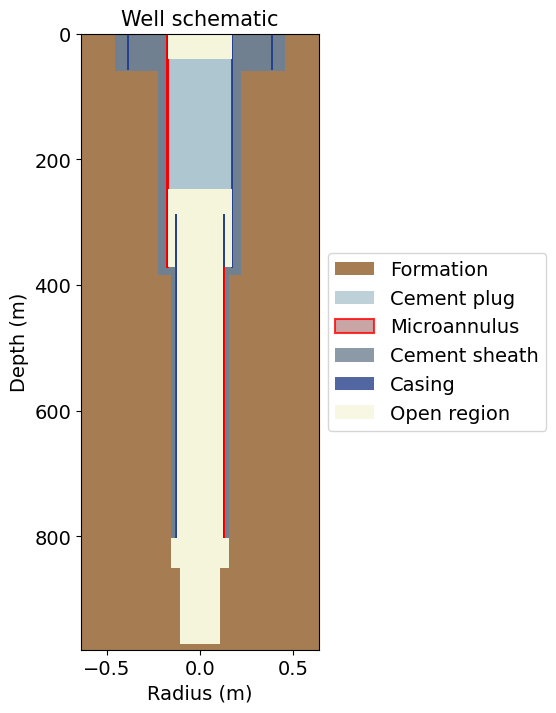

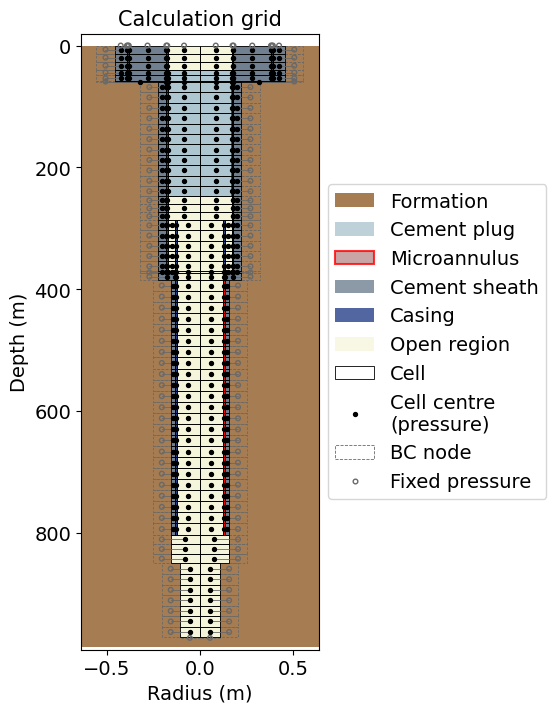

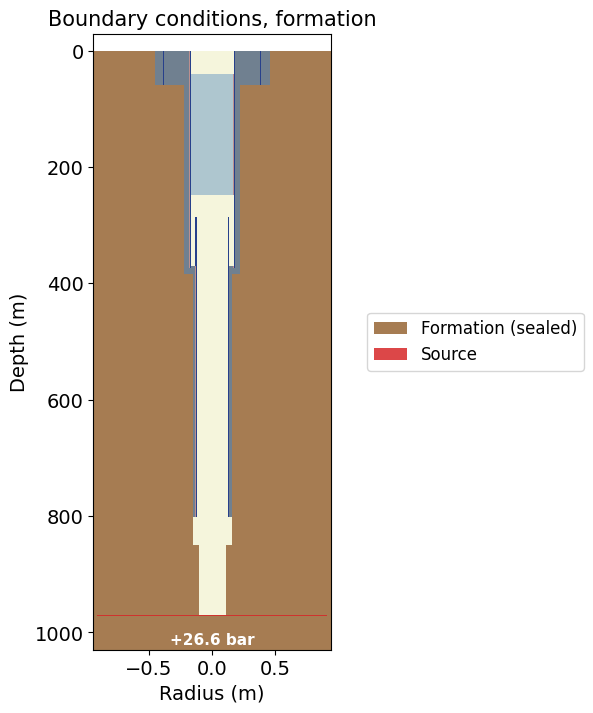

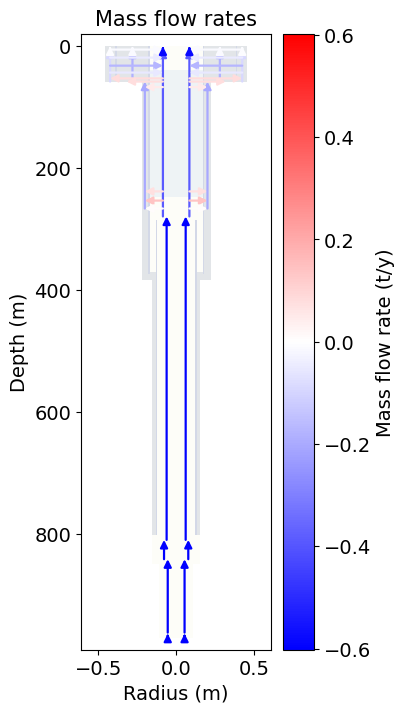

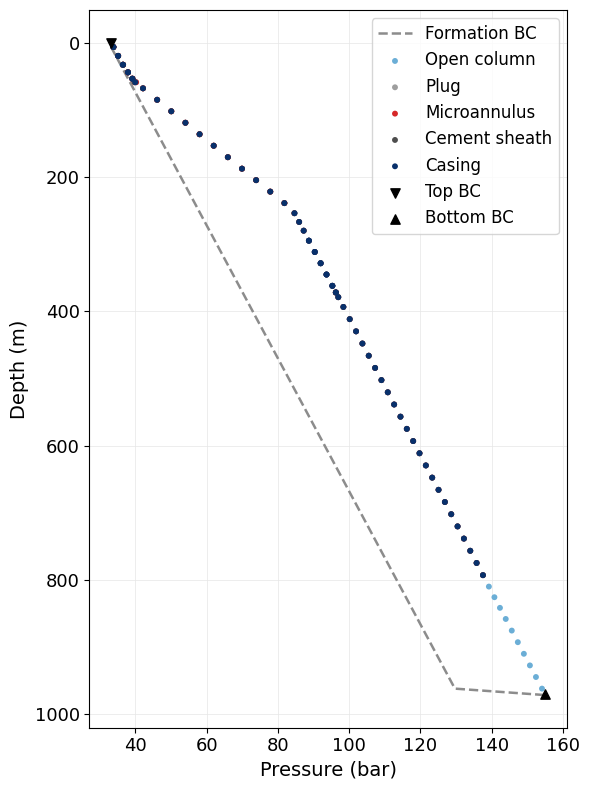


dummy_co2


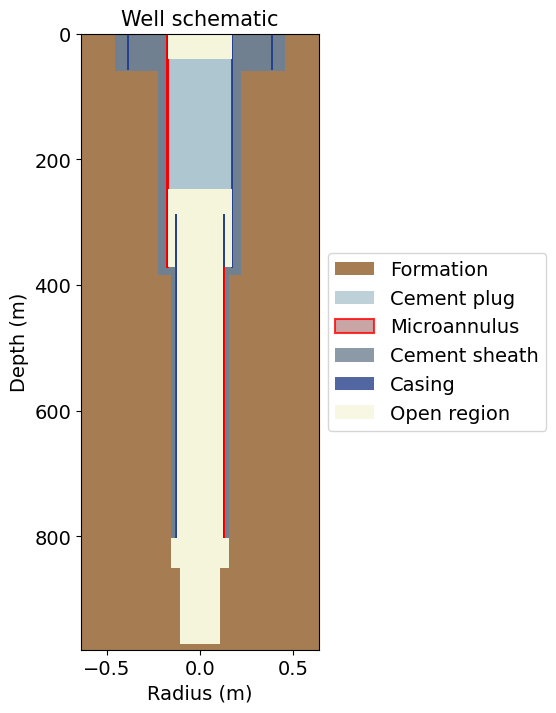

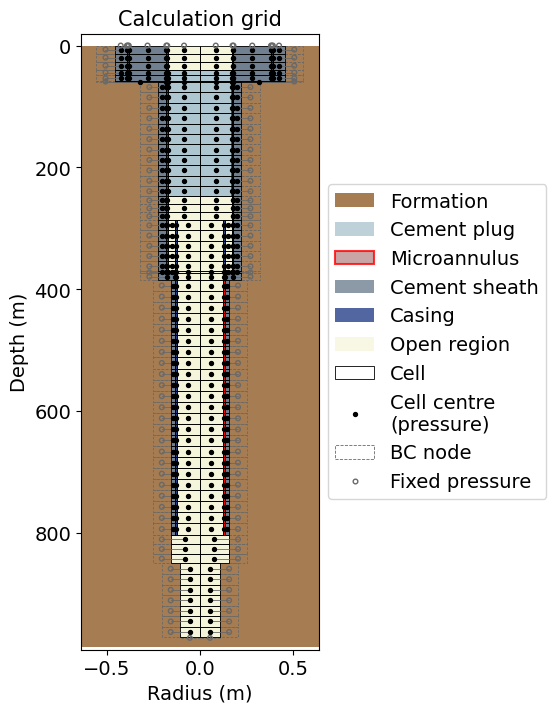

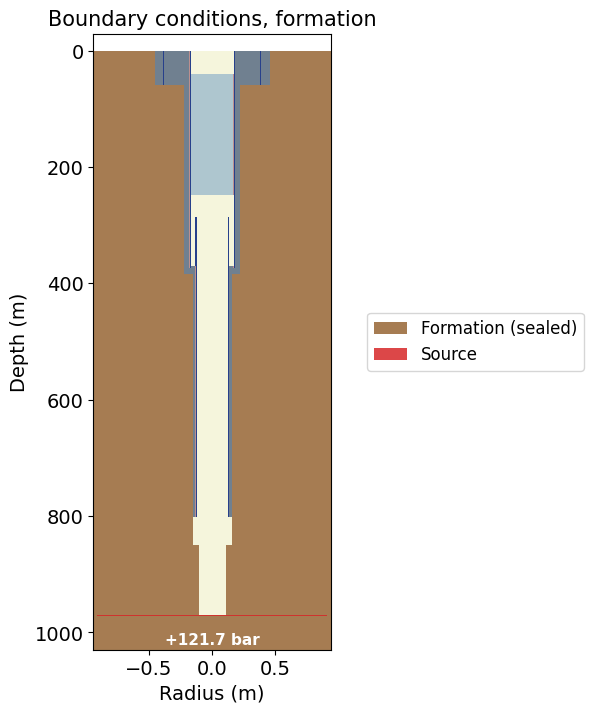

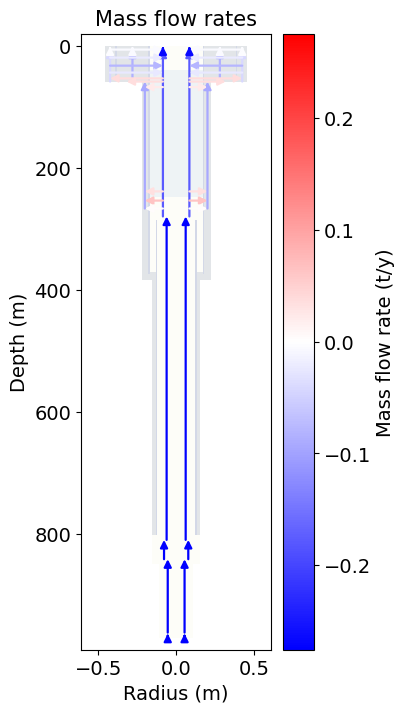

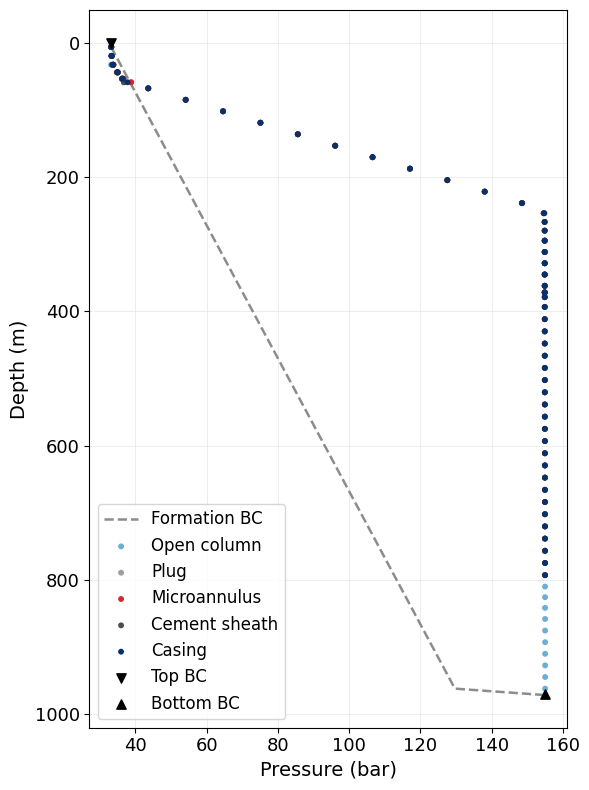


co2


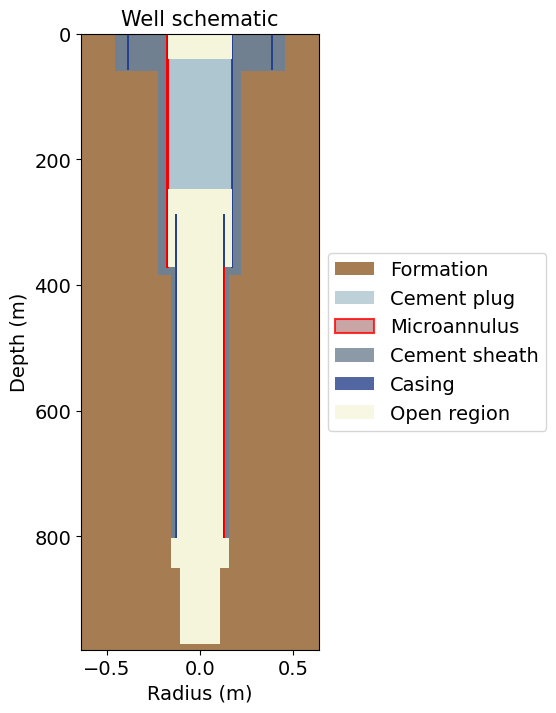

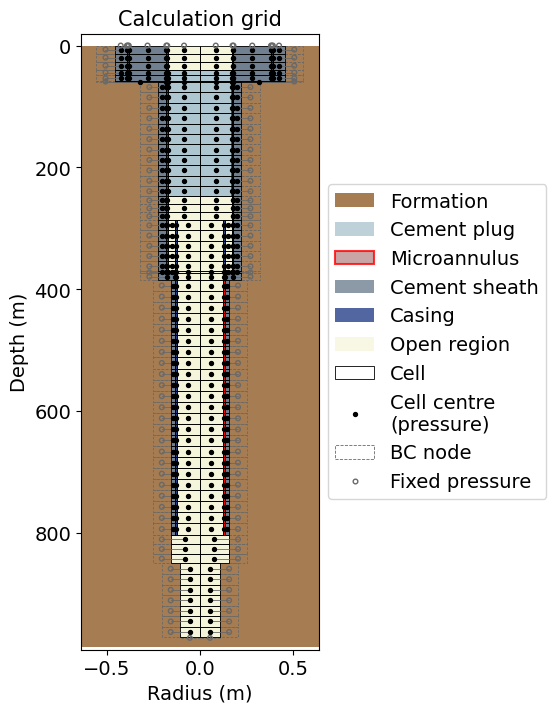

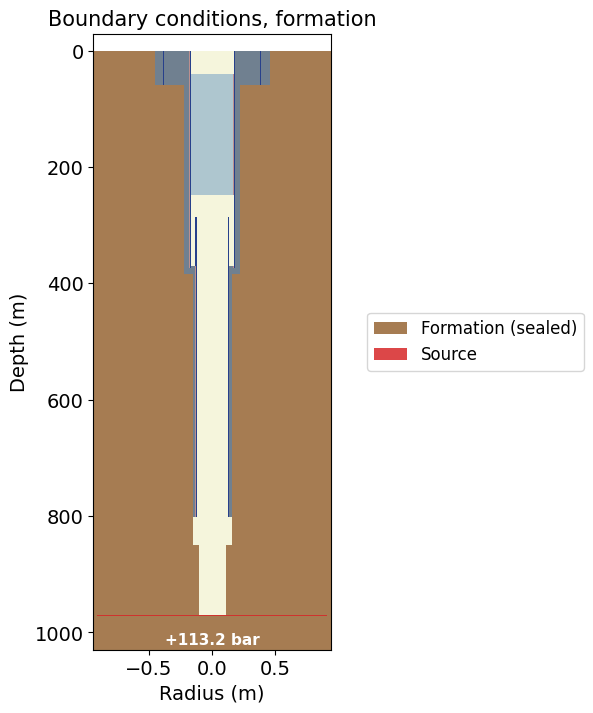

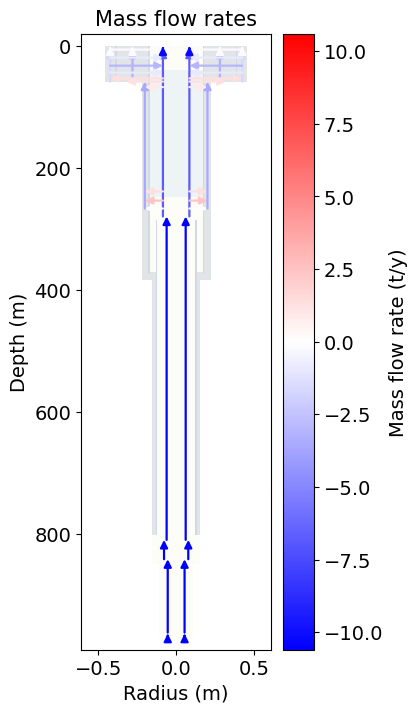

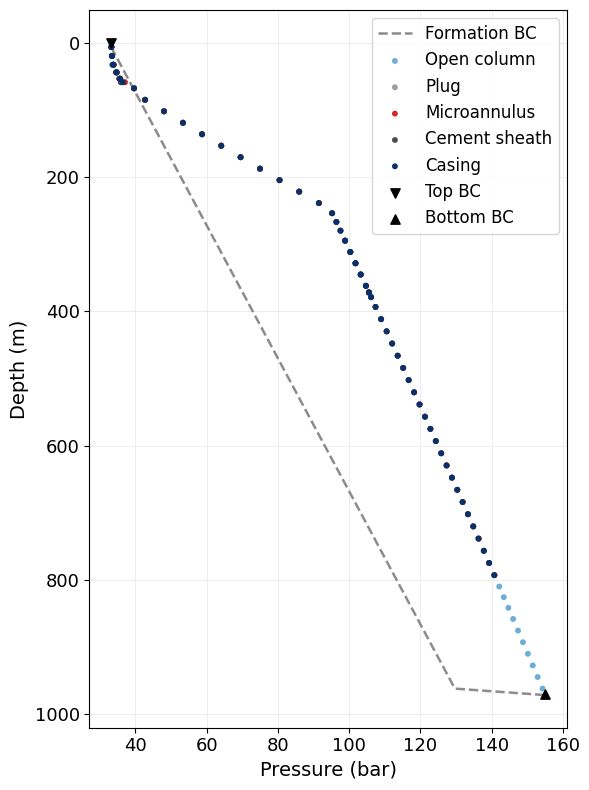

,visualization


In [ ]:
generated_visuals = []
for case_name, solver in prototype_solvers.items():
    print(case_name)
    case_visual_root = visual_root / case_name
    case_visual_root.mkdir(parents=True, exist_ok=True)
    solver.directory = str(case_visual_root)
    visualizeAll(solver, prototype_results[case_name], show=True)
    generated_visuals.extend(sorted(case_visual_root.glob("*.png")))
    print()

pd.DataFrame({
    "visualization": [path.relative_to(repo_root).as_posix() for path in generated_visuals]
})

## Assumptions and Outputs

The generated prototype CSVs, WellClass pressure profile, path inventory, and fluid-specific prototype visualizations are the benchmark artifacts. Each prototype case uses a hydrostatic pressure profile at all formation nodes, with the selected WellClass brine or fluid pressure applied only at the bottom boundary to represent overpressure.

### Important limitation: single-fluid formation coupling

Each prototype run uses one fluid model for both the wellbore and surrounding formation boundary. The CO2 case therefore treats formation inflow and outflow as CO2, not brine supplying CO2. The WellClass pressure curves provide the hydrostatic profile and bottom pressure value, but do not create a separate brine phase in the prototype. A physically explicit CO2-wellbore/brine-formation model would require multiphase or separate-fluid boundary support.

In [ ]:
assumptions = pd.DataFrame(
    [
        ["plug handling", "cement and mechanical plugs both passed as prototype plugs"],
        ["mechanical plug permeability", "SCREEN cement_perm used as effective prototype permeability"],
        ["component permeability", "shared prototype material_props used for casing/cement"],
        ["verticality", "MD approximated as vertical depth; survey not used by prototype"],
        ["pressure", "hydrostatic pressure at every node; selected WellClass brine/fluid pressure only at bottom boundary"],
        ["coordinates", "CSV tables preserve WellProcessed TVDMSL values; prototype normalizes internally after reading"],
    ], columns=["assumption", "value"]
)
assumptions

,assumption,value
0,plug handling,cement and mechanical plugs both passed as pro...
1,mechanical plug permeability,SCREEN cement_perm used as effective prototype...
2,component permeability,shared prototype material_props used for casin...
3,verticality,MD approximated as vertical depth; survey not ...
4,pressure,hydrostatic pressure at every node; selected W...
5,coordinates,CSV tables preserve WellProcessed TVDMSL value...


In [ ]:
pd.DataFrame({"artifact": [
    str(path.relative_to(repo_root))
    for path in [reference_csv, casing_csv, plug_csv, pressure_csv, path_inventory_csv, *generated_visuals]
]})

,artifact
0,notebooks/results/08B_smeaheia_leakage_tool/pr...
1,notebooks/results/08B_smeaheia_leakage_tool/pr...
2,notebooks/results/08B_smeaheia_leakage_tool/pr...
3,notebooks/results/08B_smeaheia_leakage_tool/sm...
4,notebooks/results/08B_smeaheia_leakage_tool/sm...


In [ ]:
result = prototype_results["co2"]
co2_formation_flow = result.flows.gas.formation


co2_out_kg_s = float(co2_formation_flow[co2_formation_flow > 0].sum())
co2_in_kg_s = float(-co2_formation_flow[co2_formation_flow < 0].sum())

co2_out_t_per_year = co2_out_kg_s * 365.25 * 24 * 3600 / 1000

print(f"CO2 into formation: {co2_out_kg_s:.6e} kg/s")
print(f"CO2 into formation: {co2_out_t_per_year:.6f} t/year")

CO2 into formation: 0.000000e+00 kg/s
CO2 into formation: 0.000000 t/year


In [ ]:
import re
import matplotlib.pyplot as plt

# Paste the whole text block between the triple quotes
cirrus_text = r"""
Case: TEMP-0
K Index	Depth	PRESSURE, [12, 11]
1	6.20	0.120565
2	10.60	0.148734
3	15.00	0.193237
4	19.40	0.269763
5	23.80	0.417449
6	28.20	0.706032
7	32.60	1.12635
8	37.00	1.58688
9	41.40	2.04716
10	45.80	2.50722
11	50.20	2.96713
12	54.60	3.42693
13	59.00	3.88666
14	63.40	4.34637
15	67.80	4.80608
16	72.20	5.2658
17	76.60	5.72556
18	81.00	6.18537
19	85.40	6.64522
20	89.80	7.10513
21	94.20	7.5651
22	98.60	8.02513
23	103.00	8.48522
24	107.40	8.94537
25	111.80	9.40559
26	116.20	9.86586
27	120.60	10.3262
28	125.00	10.7866
29	129.40	11.247
30	133.80	11.7076
31	138.20	12.1681
32	142.60	12.6287
33	147.00	13.0894
34	151.40	13.5501
35	155.80	14.0109
36	160.20	14.4717
37	164.60	14.9325
38	169.00	15.3934
39	173.40	15.8543
40	177.80	16.3153
41	182.20	16.7763
42	186.60	17.2373
43	191.00	17.6984
44	195.40	18.1595
45	199.80	18.6207
46	204.20	19.0819
47	208.60	19.5431
48	213.00	20.0043
49	217.40	20.4656
50	221.80	20.9269
51	226.20	21.3882
52	230.60	21.8495
53	235.00	22.3109
54	239.40	22.7723
55	243.80	23.2338
56	248.20	23.6952
57	252.60	24.1567
58	257.00	24.6182
59	261.40	25.0797
60	265.80	25.5413
61	270.20	26.0028
62	274.60	26.4644
63	279.00	26.9261
64	283.40	27.3877
65	287.80	27.8494
66	292.20	28.311
67	296.60	28.7727
68	301.00	29.2345
69	305.40	29.6962
70	309.80	30.1581
71	314.82	30.6893
72	320.46	31.2862
73	326.10	31.8832
74	331.74	32.4802
75	337.38	33.0773
76	343.02	33.6744
77	348.66	34.2716
78	354.30	35.1668
79	359.95	36.5366
80	365.59	37.9108
81	371.23	39.3222
82	376.87	40.7713
83	382.51	42.2472
84	388.15	43.7535
85	393.79	45.3056
86	399.43	46.8899
87	405.07	48.4753
88	410.71	50.0619
89	416.35	51.6496
90	421.99	53.2385
91	427.63	54.8285
92	433.27	56.4196
93	438.91	58.0118
94	444.55	59.6051
95	450.20	61.1995
96	455.84	62.7949
97	461.48	64.3914
98	467.12	65.9889
99	472.76	67.5873
100	478.40	69.1868
101	484.04	70.7872
102	489.68	72.3885
103	495.32	73.9908
104	500.96	75.594
105	506.60	77.1981
106	512.24	78.8031
107	517.88	80.4091
108	523.52	82.0161
109	529.16	83.6239
110	534.80	85.2326
111	540.45	86.8422
112	546.09	88.4526
113	551.73	90.0639
114	557.37	91.6761
115	563.01	93.289
116	568.65	94.3454
117	574.29	94.8453
118	579.93	95.3448
119	585.57	95.844
120	591.21	96.3429
121	596.85	96.8414
122	602.49	97.3403
123	608.13	97.8388
124	613.77	98.3369
125	619.41	98.8347
126	625.05	99.3322
127	630.70	99.8293
128	636.34	100.326
129	641.98	100.822
130	647.62	101.319
131	653.26	101.814
132	658.90	102.31
133	664.54	102.805
134	670.18	103.299
135	675.82	103.794
136	681.46	104.288
137	687.10	104.781
138	692.74	105.275
139	698.38	105.768
140	704.02	106.26
141	709.66	106.752
142	715.30	107.244
143	720.94	107.736
144	726.59	108.227
145	732.23	108.718
146	737.87	109.208
147	743.51	109.699
148	749.15	110.188
149	754.79	110.678
150	760.43	111.167
151	766.07	111.656
152	771.71	112.144
153	777.35	112.632
154	782.99	113.12
155	788.63	113.607
156	794.27	114.094
157	799.91	114.581
158	805.55	115.068
159	811.19	115.554
160	816.84	116.039
161	822.48	116.525
162	828.12	117.01
163	833.76	117.494
164	839.40	117.979
165	845.04	118.463
166	850.68	118.946
167	856.32	119.429
168	861.96	119.912
169	867.60	120.395
170	873.24	120.877
171	878.88	121.359
172	884.52	121.841
173	890.16	122.322
174	895.80	122.803
175	901.44	123.283
176	907.09	123.764
177	912.73	124.244
178	918.37	124.723
179	924.01	125.202
180	929.65	125.681
181	935.29	126.16
182	940.93	126.638
183	946.57	127.116
184	952.21	127.593
185	957.85	128.07
186	963.49	128.547
187	969.13	129.024
188	974.77	129.5
189	980.41	129.976
190	986.05	130.451
191	991.69	130.926
192	997.34	131.401
193	1002.98	131.876
194	1008.62	132.35
195	1014.26	132.824
196	1019.90	133.297
197	1025.54	133.77
198	1031.18	134.243
199	1036.82	134.716
200	1042.46	135.188
201	1048.10	135.66
202	1053.74	136.131
203	1059.38	136.602
204	1065.02	137.073
205	1070.66	137.544
206	1076.30	138.014
207	1081.94	138.484
208	1087.59	138.953
209	1093.23	139.423
210	1098.87	139.891
211	1104.51	140.36
212	1110.15	140.828
213	1115.79	141.296
214	1121.43	141.764
215	1127.07	142.231
216	1132.71	142.697
217	1138.35	143.164
218	1143.99	143.63
219	1149.63	144.096
220	1155.27	144.562
221	1160.91	145.027
222	1166.55	145.493
223	1172.19	145.959
224	1177.84	146.425
225	1183.48	146.891
226	1189.12	147.356
227	1194.76	147.822
228	1200.40	148.287
229	1206.04	148.752
230	1211.68	149.216
231	1219.50	149.86
232	1229.50	150.677
233	1239.50	151.493
234	1249.50	152.308
235	1259.50	153.122
236	1269.50	153.935
237	1279.50	154.747
238	1289.50	155.73
239	1299.50	156.786
240	1309.50	157.841
241	1319.50	158.897
242	1329.50	159.952
243	1339.50	161.007
244	1349.50	162.062
245	1359.50	163.117
246	1369.50	164.172
247	1379.50	165.227
248	1389.50	166.281
249	1399.50	167.336
250	1409.50	168.39
251	1419.50	169.445
252	1429.50	170.499
253	1439.50	171.553
254	1449.50	172.607
255	1459.50	173.661
256	1469.50	174.715
257	1479.50	175.769
258	1489.50	176.822
259	1499.50	177.876
260	1509.50	178.929
261	1519.50	179.982
262	1529.50	181.035
263	1539.50	182.089
264	1549.50	183.141
265	1559.50	184.194
266	1569.50	185.247
267	1579.50	186.299
268	1589.50	187.352
269	1599.50	188.404
270	1609.50	189.456"""

cirrus_depth = []
cirrus_pressure = []

for line in cirrus_text.splitlines():

    # Match: index depth pressure
    m = re.match(
        r'^\s*\d+\s+([-+]?\d*\.?\d+)\s+([-+]?\d*\.?\d+)\s*$',
        line
    )

    if m:
        cirrus_depth.append(float(m.group(1)))
        cirrus_pressure.append(float(m.group(2)))

print(f"Parsed {len(cirrus_depth)} points")

# # Plot
# plt.figure(figsize=(6,8))
# plt.plot(pressure, depth)
# plt.gca().invert_yaxis()  # depth increasing downward
# plt.xlabel("Pressure")
# plt.ylabel("Depth (m)")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

Parsed 270 points


default: p_datum=155.0 bar @ z_datum=1282.5 mMSL; p_delta=+24.4 bar; p_MSAD=114.1 bar @ z_MSAD=793.0 mMSL


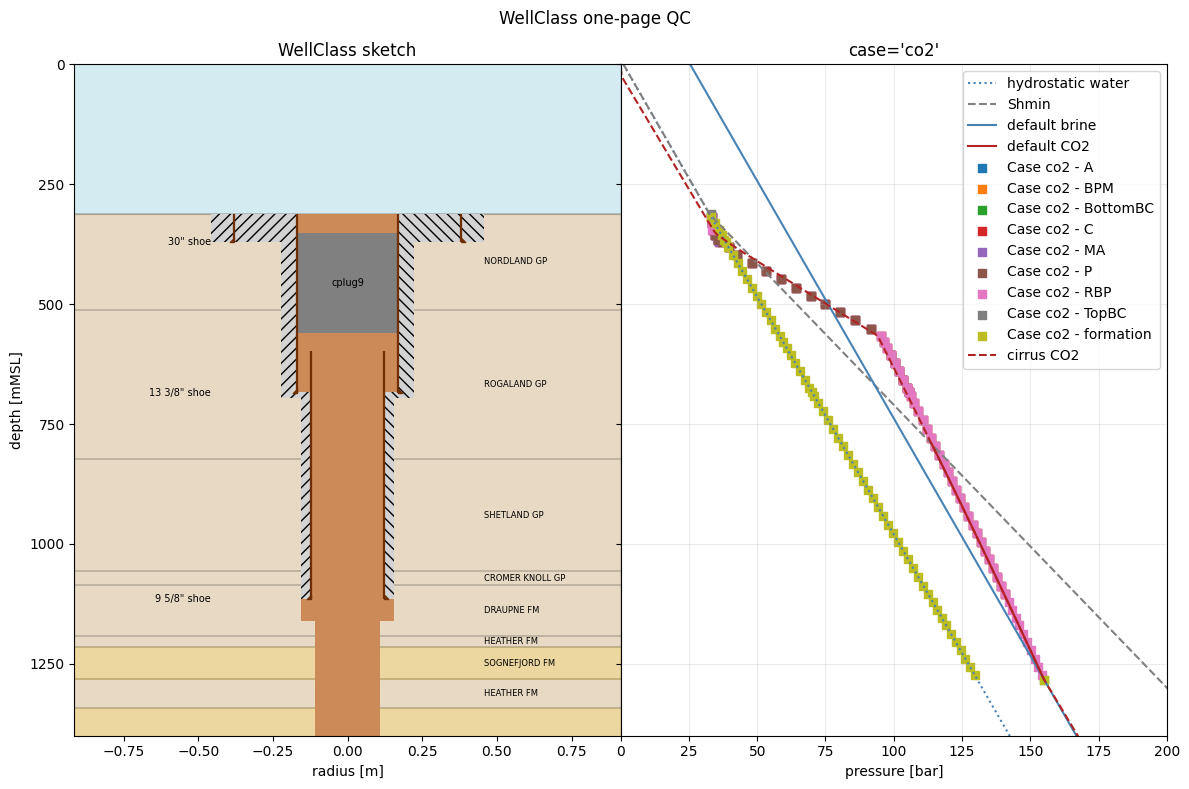

default: p_datum=155.0 bar @ z_datum=1282.5 mMSL; p_delta=+24.4 bar; p_MSAD=114.1 bar @ z_MSAD=793.0 mMSL


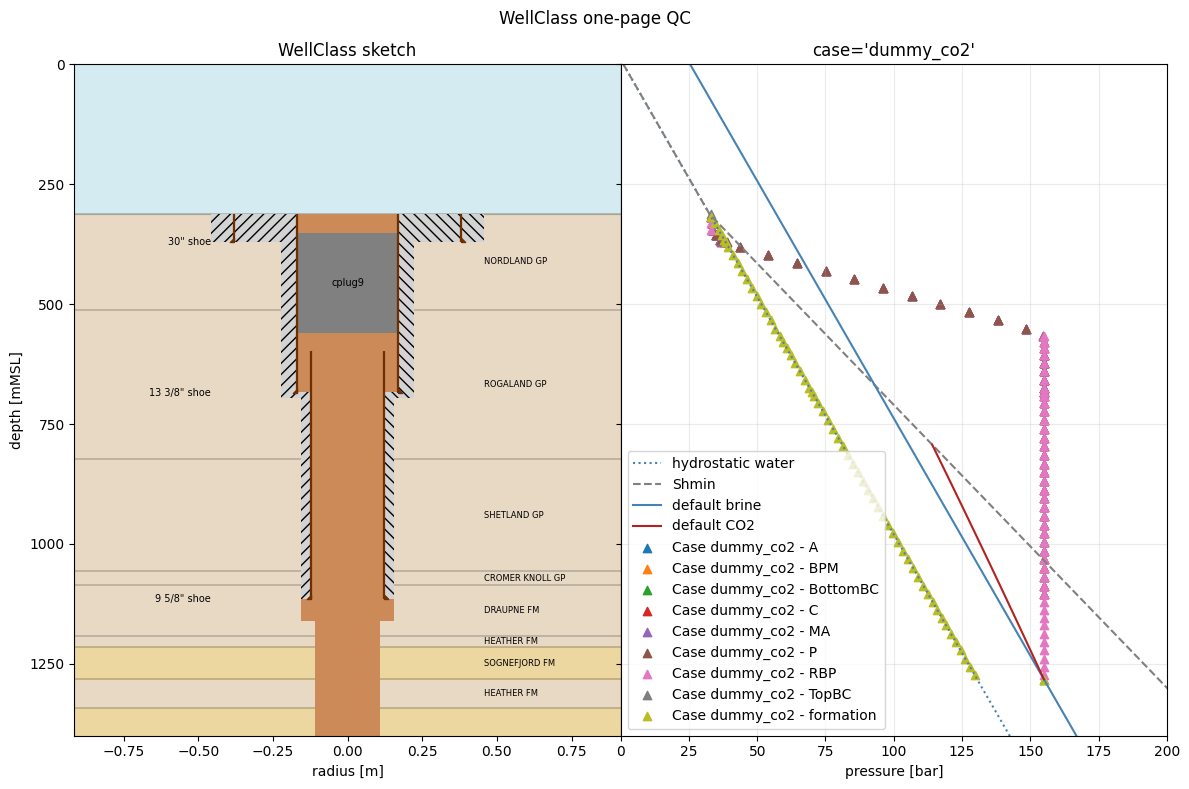

default: p_datum=155.0 bar @ z_datum=1282.5 mMSL; p_delta=+24.4 bar; p_MSAD=114.1 bar @ z_MSAD=793.0 mMSL


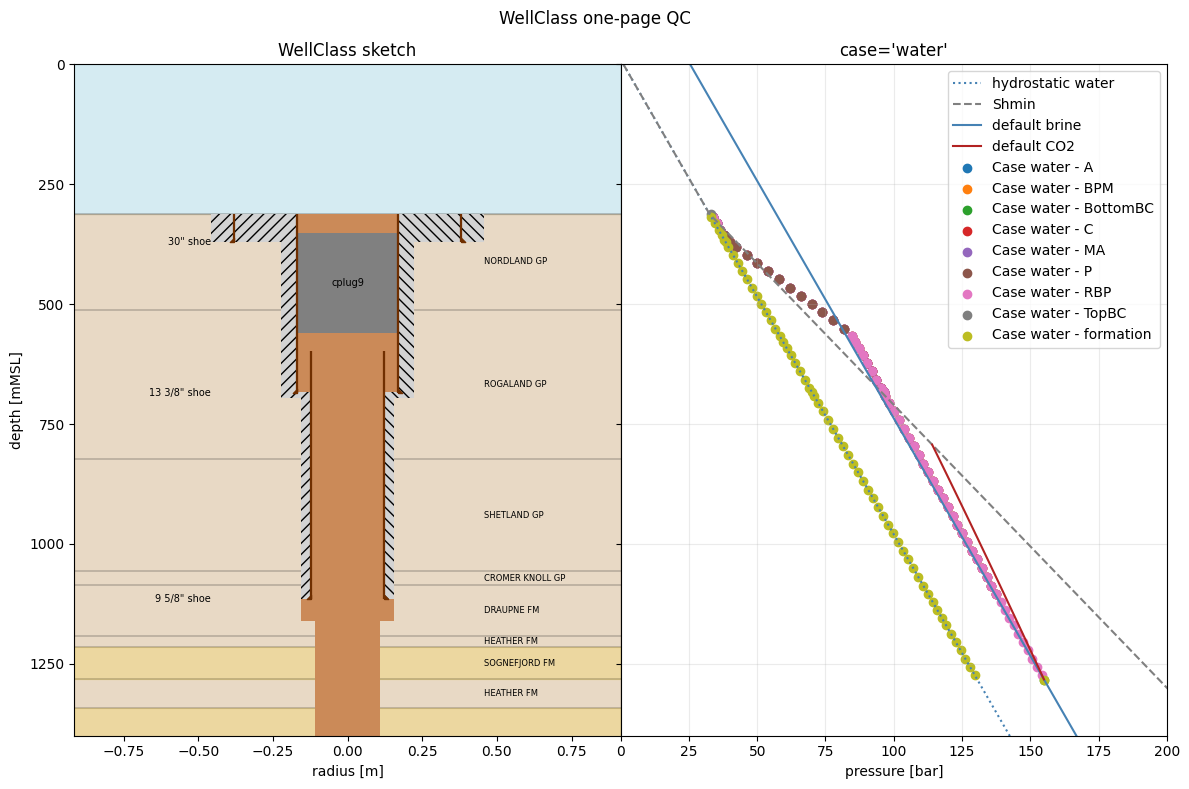

In [ ]:

import matplotlib.pyplot as plt
from src.WellClass.libs.plotting.plot_sketch import plot_sketch


pr_table = pressure.table
scenario = pressure.scenarios['base_case']
display = scenario.display_curves()


for case, data in prototype_pressure_data.groupby("case"):


    fig, (ax_well, ax_pressure) = plt.subplots(1, 2, figsize=(12, 8), sharey=True)
    plot_sketch(processed_well, ax=ax_well)
    ax_well.set_title('WellClass sketch')

    ax_pressure.plot(pr_table.hydrostatic_pressure, pr_table.depth, color='steelblue', linestyle=':', label='hydrostatic water')
    ax_pressure.plot(pr_table.min_horizontal_stress, pr_table.depth, color='gray', linestyle='--', label='Shmin')
    ax_pressure.plot(display['brine_pressure'], display['brine_depth'], color='steelblue', label='default brine')
    ax_pressure.plot(display['fluid_pressure'], display['fluid_depth'], color='firebrick', label='default CO2')
    print(
        f'default: p_datum={scenario.p_fluid_datum:.1f} bar @ z_datum={scenario.z_fluid_datum:.1f} mMSL; '
        f'p_delta={scenario.p_delta:+.1f} bar; p_MSAD={scenario.p_MSAD:.1f} bar @ z_MSAD={scenario.z_MSAD:.1f} mMSL'
    )

    ax_pressure.set_title(f'{case=}')
    ax_pressure.set_xlabel('pressure [bar]')
    ax_pressure.set_ylim(0, 1400)
    ax_pressure.set_xlim(0, 200)
    ax_pressure.invert_yaxis()
    ax_pressure.grid(alpha=0.25)

    # with wspace=0, panels butt together, so only the leftmost keeps the shared y axis
    ax_pressure.set_ylabel('')
    ax_pressure.tick_params(labelleft=False)

    # ax_pressure.scatter(prototype_pressure_data['pressure_bar'], prototype_pressure_data['depth_tvdmsl_m'], color='green', label='prototype data')

    marker_by_case = {
        "water": "o",
        "dummy_co2": "^",
        "co2": "s",
    }

    color_by_path_type = {
        "RBP": "green",
        "P": "blue",
        "C": "red",
        "MA": "purple",
        "BPM": "orange",
        "A": "brown"
    }

    for path_type, path_data in data.groupby('path_type'):
        ax_pressure.scatter(
            path_data["pressure_bar"],
            path_data["depth_tvdmsl_m"],
            marker=marker_by_case[case],
            label=f"Case {case} - {path_type}",
        )


    if case == "co2":
        ax_pressure.plot(cirrus_pressure, cirrus_depth, color='firebrick', linestyle='--', label='cirrus CO2')

    ax_pressure.legend()



    fig.suptitle('WellClass one-page QC')
    fig.tight_layout()
    fig.subplots_adjust(wspace=0)
    plt.show()

In [ ]:
bottom_solver = prototype_solvers["co2"]
bottom_well = bottom_solver.well
bottom_result = prototype_results["co2"]
bottom_flows = bottom_result.flows.total().bottom
at_bottom = bottom_well.b_idx == bottom_well.N
terminal_index = np.flatnonzero(at_bottom)[0]
terminal_node = bottom_well.b_a[terminal_index]
terminal_dp = bottom_solver._link_dps(bottom_result.p)[0]["b"][terminal_index]

bottom_link_diagnostic = pd.DataFrame({
    "quantity": [
        "terminal_link_count",
        "terminal_link_area_m2",
        "terminal_link_permeability_m2",
        "terminal_node_to_face_distance_m",
        "terminal_boundary_distance_m",
        "terminal_pressure_difference_pa",
        "terminal_link_flow_kg_s",
        "terminal_gas_flow_kg_s",
        "terminal_node_pressure_bar",
        "bottom_boundary_pressure_bar",
        "hydrostatic_formation_pressure_bar",
        "terminal_node_gas_relative_permeability",
    ],
    "value": [
        int(np.count_nonzero(at_bottom)),
        float(bottom_well.b_A[terminal_index]),
        float(bottom_well.b_kxa[terminal_index]),
        float(bottom_well.b_dxa[terminal_index]),
        float(bottom_well.bottom_BC_dist),
        float(terminal_dp),
        float(bottom_flows[terminal_index]),
        float(bottom_result.flows.gas.bottom[terminal_index]),
        float(bottom_result.p[terminal_node] / 1.0e5),
        float(bottom_solver.p_bottom / 1.0e5),
        float(bottom_solver.BC_for.p[-1] / 1.0e5),
        float(bottom_result.k_rel_gas[terminal_node]),
    ],
})
bottom_link_diagnostic

,quantity,value
0,terminal_link_count,1.000000
1,terminal_link_area_m2,0.036610
2,terminal_link_permeability_m2,0.001457
3,terminal_node_to_face_distance_m,8.642857
4,terminal_boundary_distance_m,1.000000
5,terminal_pressure_difference_pa,77984.422941
6,terminal_link_flow_kg_s,-0.000336
7,terminal_gas_flow_kg_s,-0.000336
8,terminal_node_pressure_bar,154.291149
9,bottom_boundary_pressure_bar,155.070993
